# Assignment No.4
## Classification Challenge
### Name: Negar Fathi
### Student ID: 400222069

#### 1. Data Preview

In [361]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance


In [362]:
RANDOM_STATE = 42

In [363]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [364]:
train.shape

(564, 66)

In [365]:
train.head()

,ID,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,...,feature55,feature56,feature57,feature58,feature59,feature60,feature61,feature62,feature63,label
0,0,1,1,0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,3
1,1,0,1,1,1,0,1,1,1,1,...,1,1,1,1,1,0,1,1,1,3
2,2,1,1,1,1,0,0,1,1,0,...,1,1,1,1,0,0,0,0,0,3
3,3,1,0,0,0,1,0,0,1,1,...,0,0,0,0,0,0,1,0,0,7
4,4,1,1,1,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,4


In [366]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 66 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         564 non-null    int64
 1   feature0   564 non-null    int64
 2   feature1   564 non-null    int64
 3   feature2   564 non-null    int64
 4   feature3   564 non-null    int64
 5   feature4   564 non-null    int64
 6   feature5   564 non-null    int64
 7   feature6   564 non-null    int64
 8   feature7   564 non-null    int64
 9   feature8   564 non-null    int64
 10  feature9   564 non-null    int64
 11  feature10  564 non-null    int64
 12  feature11  564 non-null    int64
 13  feature12  564 non-null    int64
 14  feature13  564 non-null    int64
 15  feature14  564 non-null    int64
 16  feature15  564 non-null    int64
 17  feature16  564 non-null    int64
 18  feature17  564 non-null    int64
 19  feature18  564 non-null    int64
 20  feature19  564 non-null    int64
 21  feature20  564 n

In [367]:
train.isnull().sum()

ID           0
feature0     0
feature1     0
feature2     0
feature3     0
            ..
feature60    0
feature61    0
feature62    0
feature63    0
label        0
Length: 66, dtype: int64

#### 2. EDA

In [368]:
train.describe()

,ID,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,...,feature55,feature56,feature57,feature58,feature59,feature60,feature61,feature62,feature63,label
count,564.00000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,...,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000
mean,281.50000,0.484043,0.448582,0.466312,0.489362,0.524823,0.423759,0.429078,0.485816,0.393617,...,0.076241,0.102837,0.085106,0.092199,0.161348,0.152482,0.145390,0.035461,0.031915,5.039007
std,162.95705,0.500189,0.497791,0.499307,0.500331,0.499827,0.494592,0.495384,0.500242,0.488985,...,0.265619,0.304015,0.279288,0.289563,0.368178,0.359807,0.352807,0.185106,0.175930,3.196674
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,140.75000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,281.50000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
75%,422.25000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
max,563.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


C:\Users\negar\AppData\Local\Temp\ipykernel_31276\1822135691.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


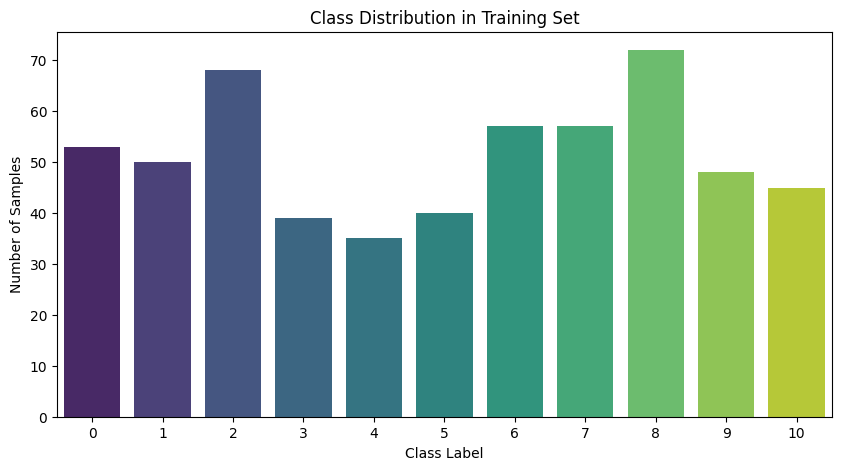

In [369]:
class_counts = train['label'].value_counts().sort_index()


plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

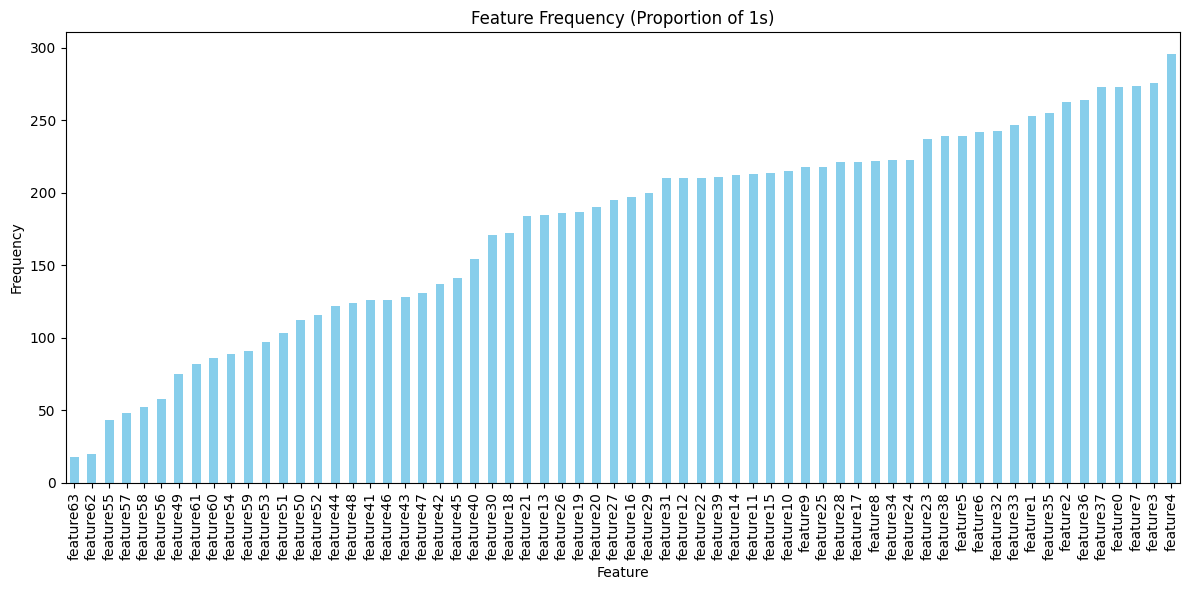

In [370]:
feature_cols = [col for col in train.columns if col.startswith('feature')]
feature_sums = train[feature_cols].sum().sort_values()

plt.figure(figsize=(12, 6))
feature_sums.plot(kind='bar', color='skyblue')
plt.title("Feature Frequency (Proportion of 1s)")
plt.ylabel("Frequency")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

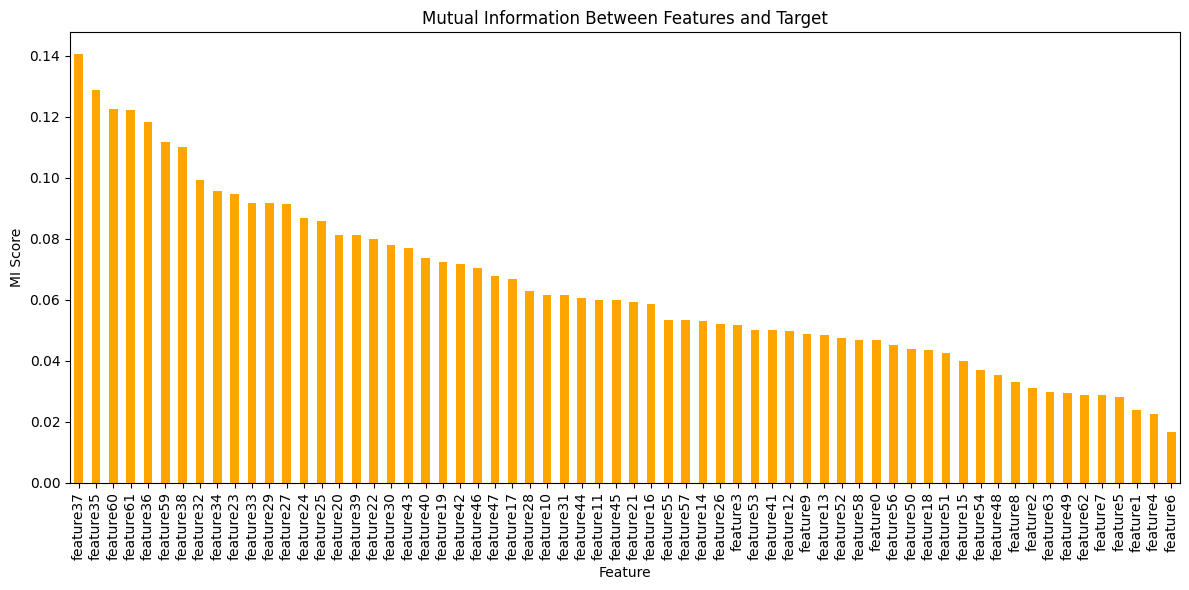

In [371]:
X = train[feature_cols]
y = train['label']
mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=RANDOM_STATE)

mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
mi_series.plot(kind='bar', color='orange')
plt.title("Mutual Information Between Features and Target")
plt.ylabel("MI Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

In [372]:
print("Top 5 informative features:\n", mi_series.head())

Top 5 informative features:
 feature37    0.140600
feature35    0.128634
feature60    0.122592
feature61    0.122069
feature36    0.118272
dtype: float64


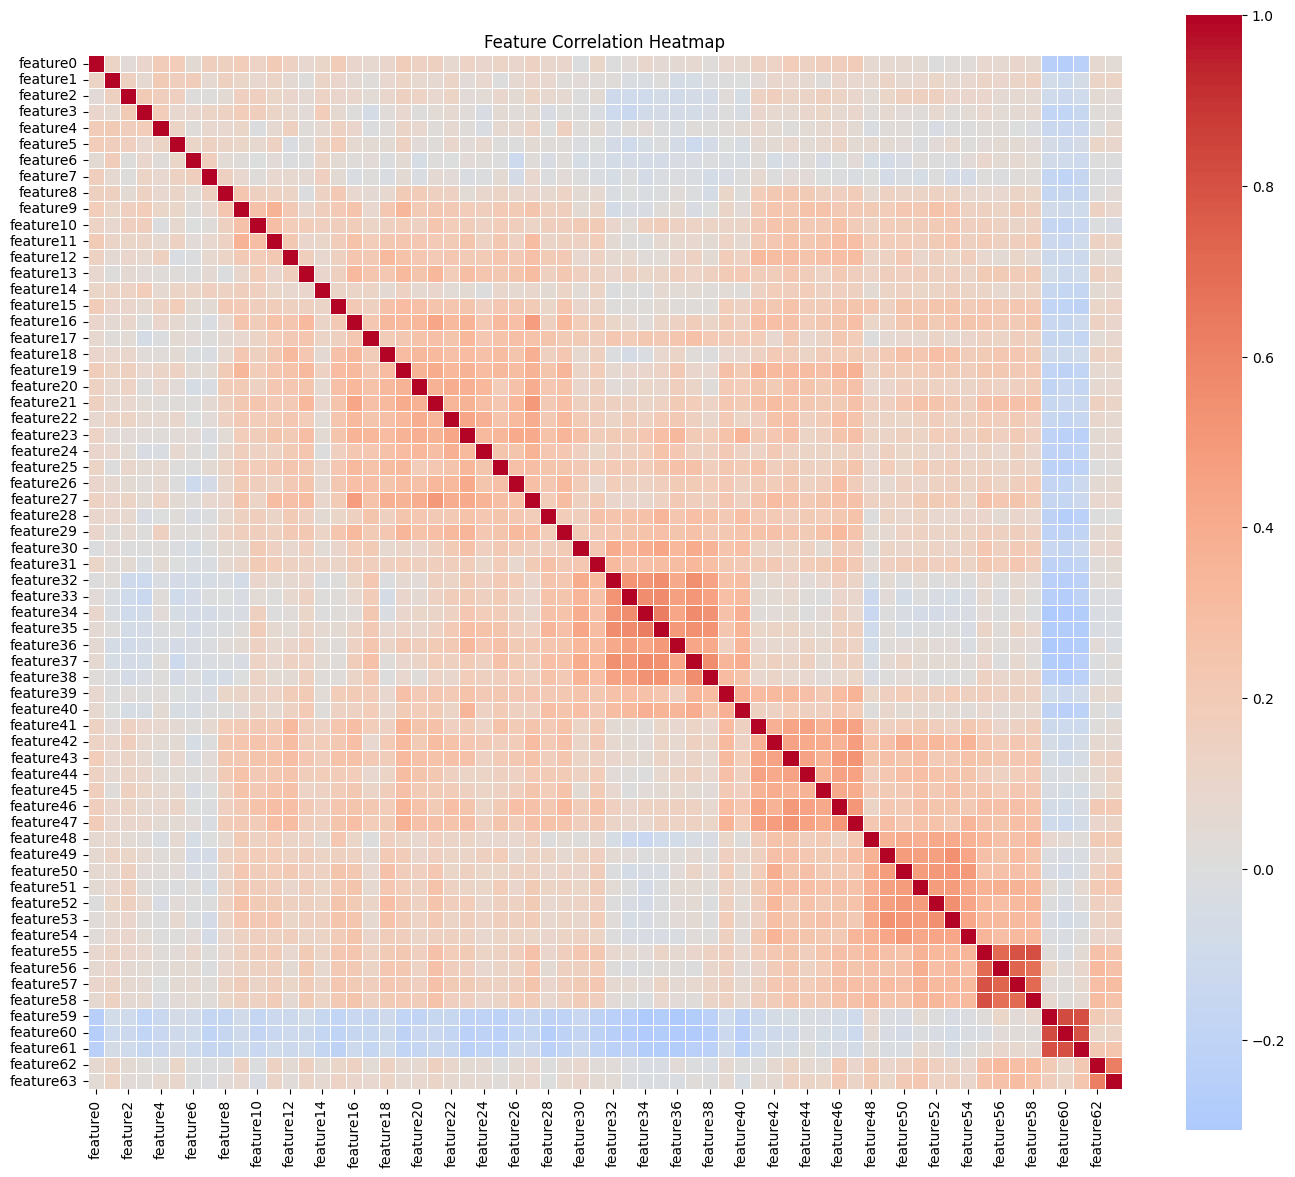

In [373]:
corr_matrix = train[feature_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

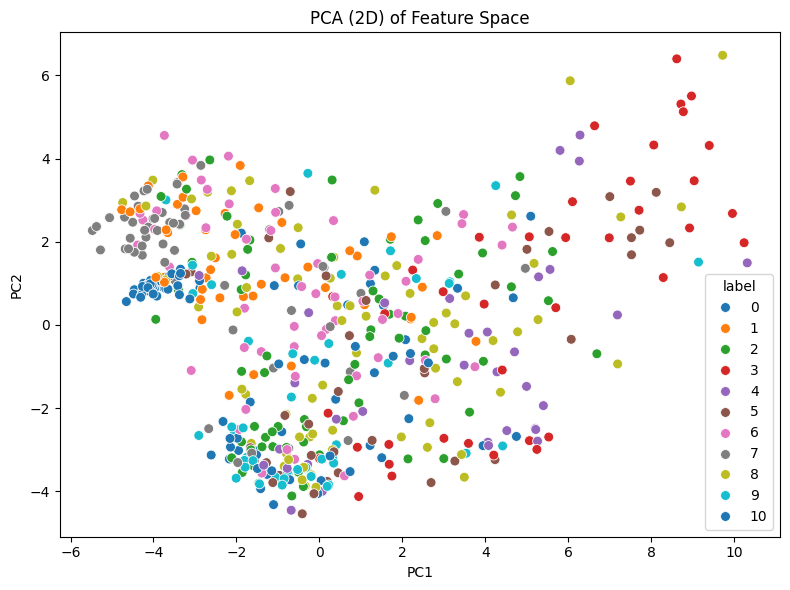

In [374]:
X = train[feature_cols]
y = train["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette='tab10', s=50)
plt.title("PCA (2D) of Feature Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

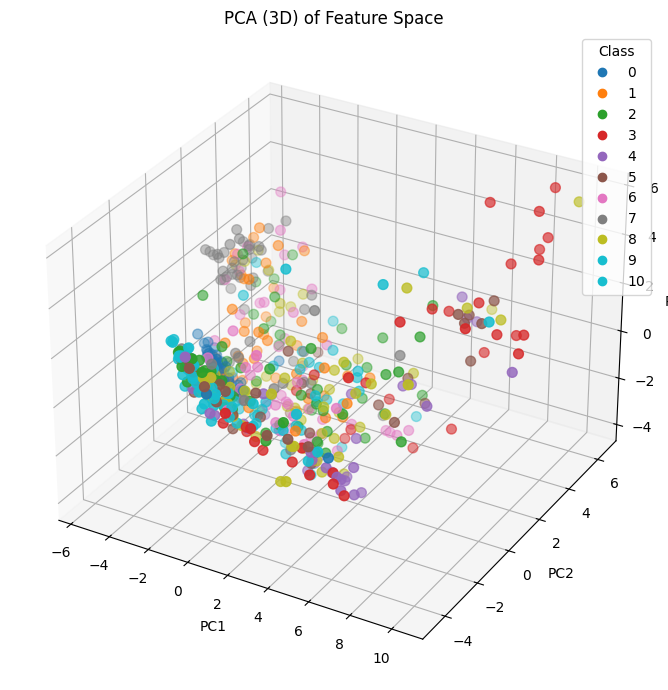

In [375]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='tab10', s=50)
ax.set_title("PCA (3D) of Feature Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Class")
plt.tight_layout()
plt.show()

#### 3. Baseline Models

In [376]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### 3.1 Logistic Regression

In [377]:
lr = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.34513274336283184


##### 3.2 SVM

In [378]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

print("SVM (RBF) Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))

SVM (RBF) Accuracy: 0.37168141592920356


##### 3.3 Naive Bayes

In [379]:
nb = BernoulliNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.3805309734513274


#### 4. Ensemble Methods

##### 4.1 Random Forest

In [380]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.3185840707964602


##### 4.2 Extremely Randomized Trees

In [381]:
et = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, y_pred_et))

Extra Trees Accuracy: 0.3008849557522124


##### 4.3 XGBoost

In [382]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

c:\Users\negar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:37:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.3185840707964602


##### 4.4 Catboost

In [383]:
cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_state=RANDOM_STATE
)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred_cat))

CatBoost Accuracy: 0.36283185840707965


##### 4.5 LightGBM

In [384]:
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 124
[LightGBM] [Info] Number of data points in the train set: 451, number of used features: 62
[LightGBM] [Info] Start training from score -2.373798
[LightGBM] [Info] Start training from score -2.422588
[LightGBM] [Info] Start training from score -2.122483
[LightGBM] [Info] Start training from score -2.677480
[LightGBM] [Info] Start training from score -2.779263
[LightGBM] [Info] Start training from score -2.645731
[LightGBM] [Info] Start training from score -2.282826
[LightGBM] [Info] Start training from score -2.282826
[LightGBM] [Info] Start training from score -2.051024
[LightGBM] [Info] Start training from score -2.473881
[LightGBM] [Info] Start training from score -2.527948
[LightGBM] [Warning] No further splits with positive gai

##### 5. Voting Classifier

In [385]:
soft_voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm_rbf),
        ('nb', nb),
        ('cat', cat)
    ],
    voting='soft'
)

soft_voting_clf.fit(X_train_scaled, y_train)
y_pred_voting = soft_voting_clf.predict(X_test_scaled)

print("Soft Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))

Soft Voting Classifier Accuracy: 0.35398230088495575


In [386]:
hard_voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm_rbf),
        ('nb', nb)
    ],
    voting='hard'
)

hard_voting_clf.fit(X_train_scaled, y_train)
y_pred_voting_hard= hard_voting_clf.predict(X_test_scaled)

print("Hard Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting_hard))

Hard Voting Classifier Accuracy: 0.3893805309734513


##### 6. Stacking classifier

In [387]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm_rbf),
        ('nb', nb),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)

print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stack))

Stacking Classifier Accuracy: 0.3805309734513274


##### 7. Tuning

##### 7.1 Tuning SVM

In [388]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid_svm = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), param_grid_svm, cv=5)
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
print("Tuned SVM Accuracy:", accuracy_score(y_test, best_svm.predict(X_test_scaled)))
print("Best Parameters for SVM:", grid_svm.best_params_)

Tuned SVM Accuracy: 0.37168141592920356
Best Parameters for SVM: {'C': 1, 'gamma': 'scale'}


##### 7.2 Tuning LR

In [389]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'multi_class': ['multinomial'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

grid_lr = GridSearchCV(LogisticRegression(random_state=RANDOM_STATE), param_grid_lr, cv=5)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)

print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("Best Parameters for Logistic Regression:", grid_lr.best_params_)

Tuned Logistic Regression Accuracy: 0.3805309734513274
Best Parameters for Logistic Regression: {'C': 0.01, 'max_iter': 1000, 'multi_class': 'multinomial', 'solver': 'lbfgs'}


##### 7.3 Tuning Random Forest

In [390]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Best Parameters for Random Forest:", grid_rf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tuned Random Forest Accuracy: 0.3274336283185841
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


##### 7.4 Tuning Stacking Classifier

In [391]:
base_learners = [
    ('lr', best_lr),           
    ('svm', best_svm),        
    ('nb', nb)
]    

meta_learner = best_rf

stacking_final = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)

stacking_final.fit(X_train, y_train)
y_pred_stack_final = stacking_final.predict(X_test)

print("Tuned Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stack_final))

Tuned Stacking Classifier Accuracy: 0.35398230088495575


##### 8. Final Model

In [392]:
X = train.drop(columns=["ID", "label"])
y = train["label"]
X_test_final = test.drop(columns=["ID"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)

In [393]:
y_pred_test = hard_voting_clf.predict(X_test_scaled)

In [394]:
submission2 = pd.DataFrame({
    "ID": range(len(y_pred_test)),
    "label": y_pred_test
})
submission2.to_csv("submission2.csv", index=False)
print("submission.csv created.")

submission.csv created.


##### 9. Feature Importance

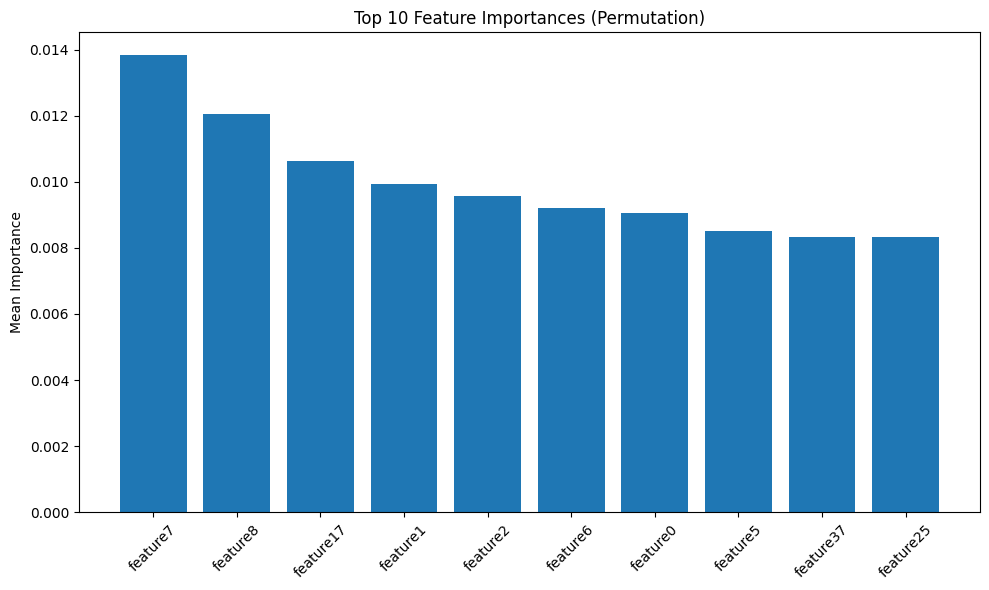

In [395]:
model_for_importance = cat
result = permutation_importance(model_for_importance, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[::-1][:10]
plt.figure(figsize=(10, 6))
plt.bar(range(10), result.importances_mean[sorted_idx])
plt.xticks(range(10), [f"feature{idx}" for idx in sorted_idx], rotation=45)
plt.ylabel("Mean Importance")
plt.title("Top 10 Feature Importances (Permutation)")
plt.tight_layout()
plt.show()

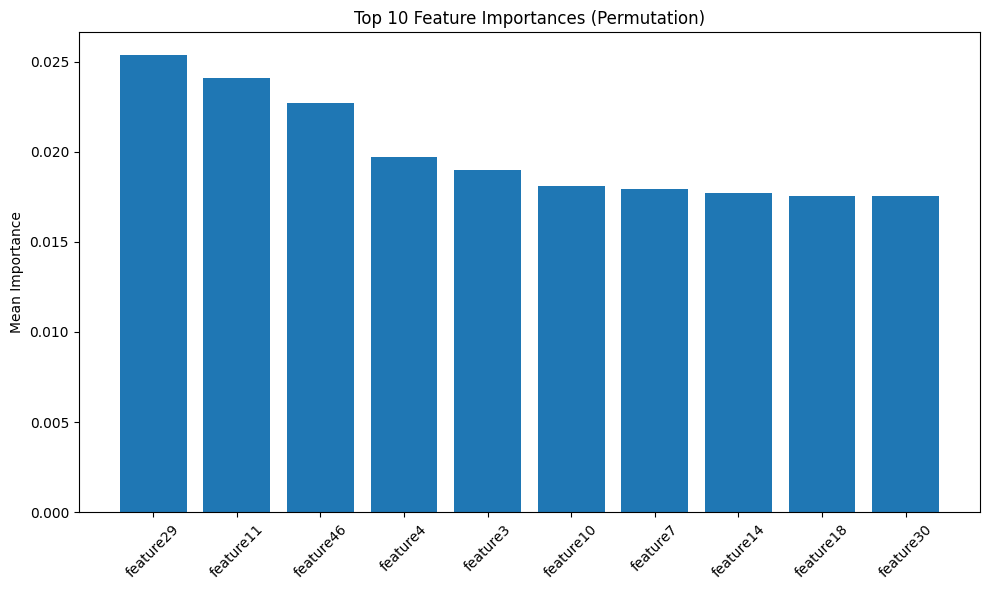

In [396]:
model_for_importance = svm_rbf
result = permutation_importance(model_for_importance, X_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()[::-1][:10]
plt.figure(figsize=(10, 6))
plt.bar(range(10), result.importances_mean[sorted_idx])
plt.xticks(range(10), [f"feature{idx}" for idx in sorted_idx], rotation=45)
plt.ylabel("Mean Importance")
plt.title("Top 10 Feature Importances (Permutation)")
plt.tight_layout()
plt.show()